In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 6]

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import tree

#from chi_sq_distr_func import chi_sq_cdf, chi_sq_cdf_sim

In [2]:
def get_node_metrics(rt):
    n_nodes = rt.tree_.node_count
    children_left = rt.tree_.children_left
    children_right = rt.tree_.children_right
    impurities = rt.tree_.impurity
    sample_size = rt.tree_.n_node_samples
    values = rt.tree_.value
    
    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    ratios = -1*np.ones(shape=n_nodes, dtype=np.float64)
    pvals = -1*np.ones(shape=n_nodes, dtype=np.float64)
    
    
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        
        # If the left and right child of a node is not the same we have a split
        # node
        is_split_node = children_left[node_id] != children_right[node_id]
        
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
            
            mse = impurities[node_id]
            mse_left = impurities[children_left[node_id]]
            mse_right = impurities[children_right[node_id]]
        
            n = sample_size[node_id]
            n_left = sample_size[children_left[node_id]]
            n_right = sample_size[children_right[node_id]]

            mse *= n/(n-1)
            mse_left *= n_left/(n_left-1)
            mse_right *= n_right/(n_right-1) 
            
            msep1 = (n_left + 1)*mse_left + (n_right + 1)*mse_right
            msep0 = (n + 1)*mse
        
            r = msep1/msep0
        
            ratios[node_id] = r
        
            # Calculate P-values here
            l_neg = -r*(n + 1)/(n-1)
            l_left = (n_left + 1)/(n_left - 1) + l_neg
            l_right = (n_right + 1)/(n_right - 1) + l_neg

            # Calcualte Pvals using our mse
            
            #p = chi_sq_cdf(0, [n_left - 1, n_right - 1, 1] , [l_left, l_right, l_neg])
            #pvals[node_id] = p[0]
            
            p = chi_sq_cdf_sim(0, [n_left - 1, n_right - 1, 1] , [l_left, l_right, l_neg], int(1e5))
            pvals[node_id] = p
        else:
            is_leaves[node_id] = True

    return pvals, ratios, values, node_depth

In [3]:
std = 1 # sigma

N = int(1e2)
X = np.random.uniform(size=(N,1))
y =  10 + 10*(X[:,0] > 0.7) - 25*(X[:,0] < 0.2) + 3*(X[:,0] < 0.5)
#y = np.sin(2*np.pi*X[:,0])

eps = np.random.normal(0, std, size=N)
y = y + eps

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [82]:
rt = tree.DecisionTreeRegressor(random_state=0, max_depth=4)
rt.fit(X_train,y_train)
path = rt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
#_ = tree.plot_tree(rt)

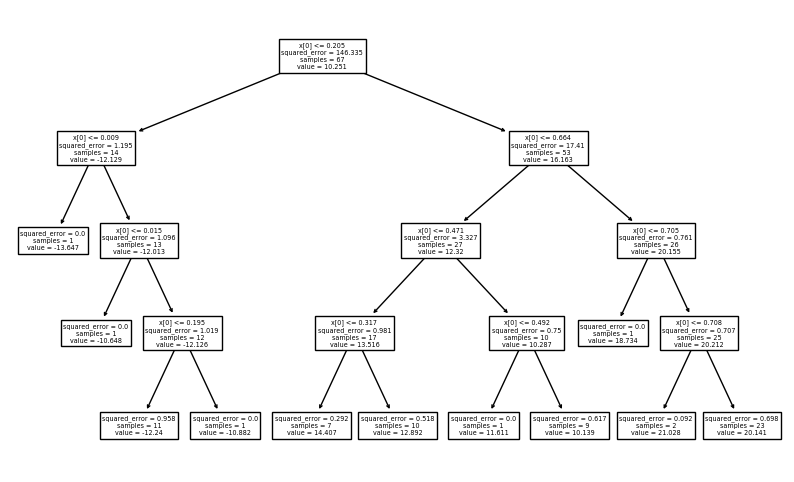

In [83]:
rt = tree.DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alphas[0], max_depth=4)
rt.fit(X_train,y_train)
_ = tree.plot_tree(rt)

y_pred = rt.predict(X_test)
global_msep = mean_squared_error(y_test, y_pred)

#pvals, ratios, values, node_depth = get_node_metrics(rt)
#significance = np.sum([i for i in pvals if i>=0.0])

#print(f"Tree depth: {np.max(node_depth)} \n\
#MSEP from test data: {global_msep} \n\
#Significance: {100*significance}%")

In [89]:
splitting_sequence

array([ 0,  8,  9, 10,  1, 16,  3, 13,  5, 18])

In [88]:
# Since the reduction for each split is monotone,
# we can order the reduction per split and get the 
# sequence in which the ccp tree grows. 
# Here, calculate the reduction in each splitting node.

n_nodes = rt.tree_.node_count
children_left = rt.tree_.children_left
children_right = rt.tree_.children_right
impurities = rt.tree_.impurity
sample_size = rt.tree_.n_node_samples

node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
is_leaves = np.zeros(shape=n_nodes, dtype=bool)

reduction = np.nan*np.ones(shape=n_nodes, dtype=np.float64)

stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
while len(stack) > 0:
    # `pop` ensures each node is only visited once
    node_id, depth = stack.pop()
    node_depth[node_id] = depth
    
    # If the left and right child of a node is not the same we have a split
    # node
    is_split_node = children_left[node_id] != children_right[node_id]
    
    # If a split node, append left and right children and depth to `stack`
    # so we can loop through them
    if is_split_node:
        stack.append((children_left[node_id], depth + 1))
        stack.append((children_right[node_id], depth + 1))
        
        mse = impurities[node_id]
        mse_left = impurities[children_left[node_id]]
        mse_right = impurities[children_right[node_id]]
    
        n = sample_size[node_id]
        n_left = sample_size[children_left[node_id]]
        n_right = sample_size[children_right[node_id]]

        red = (n_left*mse_left + n_right*mse_right - n*mse)/len(y_train)
        reduction[node_id] = red
    else:
        is_leaves[node_id] = True


splitting_sequence = np.argsort(reduction)[:-np.sum(np.isnan(reduction))] # order and remove the leave indices
splitting_sequence

array([ 0,  8,  9, 10,  1, 16,  3, 13,  5, 18])

In [379]:
# Testing Impurities are the correct mse
# They are! Except 1/n so make sure to reweight them
# If this is not satisfactory, we can use the tree_.decision_path to get the node the data flows in.

left_data_ind = X_train <= 0.2
right_data_ind = ~(X_train <= 0.2)
left_y = y_train[left_data_ind.reshape(-1)]
right_y = y_train[right_data_ind.reshape(-1)]
np.var(right_y, ddof=0)

17.39692415236081

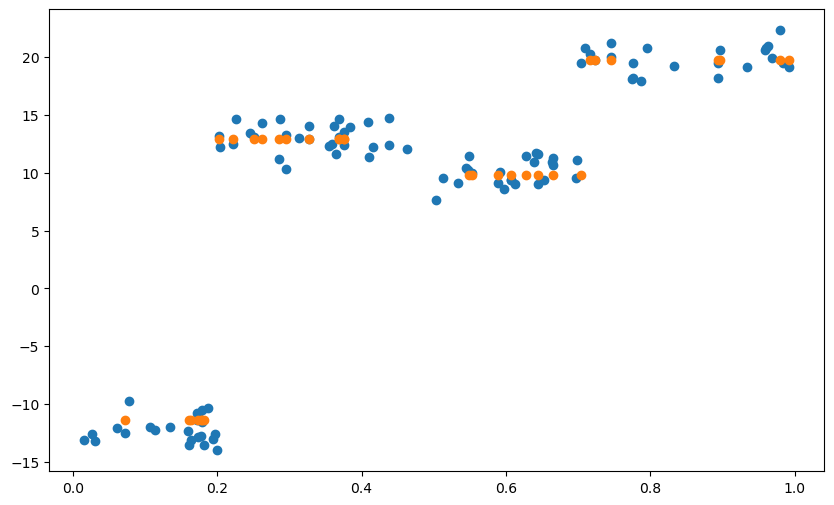

In [380]:
y_pred = rt.predict(X_test)
plt.scatter(X,y)
plt.scatter(X_test,y_pred)

In [ ]:
trees = []
for c in ccp_alphas[-4:]:
    clf = tree.DecisionTreeRegressor(random_state=0, ccp_alpha=c, max_depth=3)
    clf.fit(X_train, y_train)
    trees.append(clf)

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

In [ ]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
ax[2].plot(ccp_alphas, impurities[:-1], marker="o", drawstyle="steps-post")
ax[2].set_xlabel("effective alpha")
ax[2].set_ylabel("total impurity of leaves")
ax[2].set_title("Total Impurity vs effective alpha for training set")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(12,6))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

# Testing Z_r distribution